**Instituto Brasileiro de Ensino, Desenvolvimento e Pesquisa**

Programa de Pós-Graduação em Administração Pública — Mestrado Profissional

**Disciplina:** Avaliação de Políticas Públicas com Dados  
**Atividade:** Planejamento de um experimento aleatorizado  
**Grupo:** Analécia Borato, Fabricio Santana, Giovane Brígido, Paulo Ceser

# Oferta aleatorizada do Programa Mais Médicos em municípios de Goiás

[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fabriciosantana/mcdia/blob/main/09-appd/assignments/02-experimento-aleatorizado-mais-medicos/atividade_experimento_aleatorizado_mais_medicos.ipynb)

Este notebook planeja, de forma prospectiva e hipotética, um experimento para
avaliar a **oferta prioritária de provimento médico pelo Programa Mais Médicos
(PMM)**. Os 246 municípios de Goiás são usados como clusters elegíveis, e a
base da atividade anterior fornece parâmetros de planejamento — média,
variância e poder preditivo da taxa prévia —, não resultados de um experimento
que tenha ocorrido.

> **Decisão de desenho:** randomizar a oferta do PMM no nível municipal, com
> alocação 1:1 e bloqueio por risco basal e porte. O desfecho primário é a taxa
> municipal de ICSAP; a análise principal é por intenção de tratar (ITT).

## Introdução

Um experimento aleatorizado identifica efeitos causais ao atribuir a oferta da
intervenção por sorteio. Antes da implementação, os resultados potenciais não
observados são, em expectativa, independentes da designação. Assim, diferenças
posteriores entre os grupos podem ser atribuídas à **oferta** do programa, e
não à seleção deliberada de municípios com perfis distintos.

O planejamento precisa distinguir três objetos. A **unidade de randomização**
é quem participa do sorteio; a **unidade de análise** é quem aparece no banco
final; e a **unidade de intervenção** é onde a política é implementada. Aqui,
as três são organizadas no nível do município. Os pacientes permanecem
aninhados nos municípios, razão pela qual o estudo é um experimento por
clusters do ponto de vista individual.

Também é necessário separar designação e recebimento. A variável $Z_i$ indica
se o município foi sorteado para receber oferta prioritária; $D_i$ indica se o
provimento foi efetivamente implementado; e $Y_i$ é a taxa posterior de ICSAP.
O sorteio identifica diretamente o efeito de $Z$, o ITT. O efeito do
recebimento $D$ exige hipóteses adicionais e pode ser estimado como LATE quando
$Z$ funciona como instrumento válido.

O notebook primeiro descreve a intervenção e os dados de planejamento; depois
justifica a randomização por clusters e o bloqueio, calcula o tamanho de
amostra e ilustra uma alocação; em seguida apresenta o plano de análise, a
não-conformidade e a distinção ITT–LATE; por fim discute ética, validade externa
e limitações.

## Intervenção, pergunta e estimandos

O experimento é formulado como se fosse planejado antes de uma expansão com
capacidade limitada do PMM. Municípios no grupo de tratamento recebem, no
início do ciclo, **oferta prioritária de vagas, apoio à adesão e início do
provimento**. Municípios no grupo de comparação permanecem no fluxo regular e
formam uma lista de espera, sem perda dos serviços de saúde já existentes.

**Pergunta principal:** qual é o efeito de ser sorteado para a oferta
prioritária do PMM sobre a média da taxa anual de internações por condições
sensíveis à atenção primária nos dois anos seguintes?

| Elemento | Definição planejada |
|---|---|
| População | 246 municípios de Goiás elegíveis antes do sorteio |
| Designação $Z_i$ | 1 para oferta prioritária; 0 para fluxo regular/lista de espera |
| Recebimento $D_i$ | ao menos um profissional ativo dentro da janela definida no protocolo |
| Desfecho $Y_i$ | média das taxas anuais de ICSAP por 10 mil habitantes nos dois anos posteriores |
| Linha de base | taxa de ICSAP medida antes do sorteio |
| Estimando primário | ITT da oferta prioritária |
| Estimando secundário | LATE do provimento efetivo para os municípios conformes |

Formalmente, o estimando primário é

$$ITT=E[Y_i\mid Z_i=1]-E[Y_i\mid Z_i=0].$$

O sentido esperado é negativo: maior disponibilidade de atenção primária pode
prevenir internações evitáveis. A hipótese é bilateral, pois a política também
pode aumentar diagnóstico e encaminhamento no curto prazo.

## Dados usados no planejamento

Reutilizamos a base processada da atividade 1, com uma linha para cada
município. Ela combina a série histórica do PMM, internações classificadas como
ICSAP pela SES-GO/SIH-DATASUS e população municipal do SIDRA/IBGE.

Esses dados são empregados somente para estimar:

- a média e o desvio-padrão do desfecho;
- a associação entre a taxa prévia e a posterior;
- a variância residual esperada após ajuste pela linha de base;
- a distribuição de municípios por risco e porte usada no bloqueio.

Usar dados históricos no cálculo de poder é preferível a escolher uma
variância arbitrária, mas pressupõe que a dispersão de um novo ciclo seja
semelhante. Antes da implementação real, os parâmetros devem ser atualizados
com dados contemporâneos e com a definição final de elegibilidade.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from sklearn.linear_model import LinearRegression

sns.set_theme(style="whitegrid")
SEED = 20260804

def localizar_base():
    candidatos = [
        Path("../01-inferencia-causal-mais-medicos/data/processed/mais_medicos_icsap_go.csv"),
        Path("09-appd/assignments/01-inferencia-causal-mais-medicos/data/processed/mais_medicos_icsap_go.csv"),
        Path("data/processed/mais_medicos_icsap_go.csv"),
    ]
    for caminho in candidatos:
        if caminho.exists():
            return caminho
    raise FileNotFoundError("Base processada da atividade 1 não encontrada.")

df = pd.read_csv(localizar_base(), dtype={"cod_mun": str})
print(f"Municípios disponíveis para planejamento: {len(df)}")
df.head()

Municípios disponíveis para planejamento: 246


,cod_mun,municipio_residencia,regiao_saude_residencia,tratado,medicos_pmm_inicial,populacao_2014,log_populacao,taxa_icsap_pre,taxa_clinicas_pre,taxa_icsap_pos,mudanca_taxa_icsap
0,520005,ABADIA DE GOIAS,CENTRAL,0,0.0,7733,8.953252,275.934981,350.469142,326.226472,50.291491
1,520010,ABADIANIA,PIRENEUS,1,3.0,17701,9.781376,128.131132,155.835161,123.787997,-4.343135
2,520013,ACREUNA,SUDOESTE I,0,0.0,21549,9.978085,420.106712,592.530188,312.729791,-107.376921
3,520015,ADELANDIA,OESTE II,0,0.0,2554,7.845416,150.588235,211.764706,90.013472,-60.574763
4,520017,AGUA FRIA DE GOIAS,ENTORNO NORTE,0,0.0,5451,8.603554,62.279889,73.401297,37.421228,-24.858661


In [2]:
y = df["taxa_icsap_pos"].to_numpy()
X_pre = df[["taxa_icsap_pre"]]

modelo_pre = LinearRegression().fit(X_pre, y)
residuos = y - modelo_pre.predict(X_pre)

parametros = pd.Series({
    "Média posterior por 10 mil": y.mean(),
    "Desvio-padrão bruto": y.std(ddof=1),
    "Correlação pré–pós": df["taxa_icsap_pre"].corr(df["taxa_icsap_pos"]),
    "R² da taxa prévia": modelo_pre.score(X_pre, y),
    "Desvio-padrão residual": residuos.std(ddof=2),
}, name="Estimativa histórica")
parametros.round(3).to_frame()

,Estimativa histórica
Média posterior por 10 mil,362.055
Desvio-padrão bruto,248.067
Correlação pré–pós,0.820
R² da taxa prévia,0.672
Desvio-padrão residual,142.281


A taxa prévia explica parcela importante da variação posterior. Por isso, o
cálculo principal usa o desvio-padrão residual de uma ANCOVA simples, e não o
desvio-padrão bruto. Essa escolha é coerente com o plano de análise, que inclui
o desfecho basal. Ela aumenta a precisão sem usar informação posterior ao
sorteio.

O ganho deve ser tratado com cautela: a relação foi estimada na mesma amostra
histórica e pode ser menos forte em outra coorte. Por transparência, o notebook
também mostra cenários com diferentes MDEs e permite refazer o cálculo com
outro desvio-padrão.

## Escolha do desenho de aleatorização

### Por que não usar aleatorização individual

O PMM altera a oferta de profissionais e a organização da atenção básica de
todo o município. Sortear pacientes dentro da mesma rede seria operacionalmente
inviável, criaria contaminação entre grupos e não corresponderia à unidade de
decisão da política.

### Por que randomizar clusters municipais

O município é o cluster natural porque recebe a oferta, organiza as equipes e
é a unidade da taxa de ICSAP. A randomização municipal reduz contaminação
interna e alinha designação, implementação e análise. Persistem possíveis
spillovers entre municípios — deslocamento de pacientes e profissionais —, que
devem ser monitorados.

### Por que bloquear em vez de usar sorteio simples

Com 246 clusters, o sorteio simples é válido em expectativa, mas pode gerar
desequilíbrio por acaso em risco basal e porte. O desenho proposto faz
**randomização por clusters com bloqueio**, usando quartis da taxa prévia de
ICSAP e tercis da população. Dentro de cada um dos 12 estratos, aproximadamente
metade recebe oferta prioritária. A região de saúde será usada como restrição
de balanceamento e covariável pré-especificada, pois algumas regiões têm poucos
municípios e um cruzamento completo região × risco produziria estratos muito
pequenos.

Comparação dos desenhos:

| Desenho | Vantagem | Limitação | Decisão |
|---|---|---|---|
| Simples entre municípios | implementação e análise fáceis | pode desequilibrar risco, porte e território | não escolhido |
| Estratificado em indivíduos | melhora precisão individual | incompatível com intervenção municipal | não escolhido |
| Cluster municipal sem bloqueio | respeita a implementação | pode gerar desequilíbrio com poucos clusters | insuficiente sozinho |
| Cluster municipal bloqueado | respeita a política e protege o equilíbrio basal | exige protocolo e análise compatíveis com os blocos | escolhido |

## MDE, poder e tamanho de amostra

Adotamos teste bilateral com nível de significância de 5%, poder de 80% e
alocação 1:1. Para uma análise municipal com ajuste pela taxa prévia, a
aproximação do número total de clusters é

$$N=\frac{4(z_{1-\alpha/2}+z_{1-\beta})^2\sigma_{res}^2}{\delta^2},$$

em que $\sigma_{res}$ é o desvio-padrão residual e $\delta$ é o MDE em
internações por 10 mil habitantes.

Um MDE de **52 internações por 10 mil** corresponde a aproximadamente 14% da
média histórica. É uma mudança substantivamente relevante, compatível com uma
expansão intensiva da atenção primária, embora efeitos menores também possam
ser importantes para a política.

In [3]:
alpha = 0.05
poder = 0.80
sigma_res = residuos.std(ddof=2)
z_soma = norm.ppf(1 - alpha / 2) + norm.ppf(poder)

def clusters_necessarios(mde, sigma=sigma_res):
    return 4 * (z_soma ** 2) * (sigma ** 2) / (mde ** 2)

mdes = np.arange(40, 71, 5)
tabela_poder = pd.DataFrame({"MDE": mdes})
tabela_poder["Clusters necessários"] = np.ceil(
    [clusters_necessarios(mde) for mde in mdes]
).astype(int)
tabela_poder["Com 5% de perda"] = np.ceil(
    tabela_poder["Clusters necessários"] / 0.95
).astype(int)
tabela_poder["% da média histórica"] = 100 * tabela_poder["MDE"] / y.mean()
tabela_poder.round(1)

,MDE,Clusters necessários,Com 5% de perda,% da média histórica
0,40,398,419,11.0
1,45,314,331,12.4
2,50,255,269,13.8
3,55,211,223,15.2
4,60,177,187,16.6
5,65,151,159,18.0
6,70,130,137,19.3


In [4]:
mde_alvo = 52
n_sem_perda = int(np.ceil(clusters_necessarios(mde_alvo)))
n_com_perda = int(np.ceil(n_sem_perda / 0.95))
n_disponivel = len(df)
n_efetivo_5 = int(np.round(n_disponivel * 0.95))
mde_com_5 = 2 * z_soma * sigma_res / np.sqrt(n_efetivo_5)

resumo_amostra = pd.Series({
    "MDE-alvo por 10 mil": mde_alvo,
    "Clusters necessários sem perda": n_sem_perda,
    "Clusters necessários com 5% de perda": n_com_perda,
    "Clusters disponíveis": n_disponivel,
    "Clusters efetivos após 5% de perda": n_efetivo_5,
    "MDE alcançável após 5% de perda": mde_com_5,
}, name="Planejamento")
resumo_amostra.round(2).to_frame()

,Planejamento
MDE-alvo por 10 mil,52.00
Clusters necessários sem perda,236.00
Clusters necessários com 5% de perda,249.00
Clusters disponíveis,246.00
Clusters efetivos após 5% de perda,234.00
MDE alcançável após 5% de perda,52.12


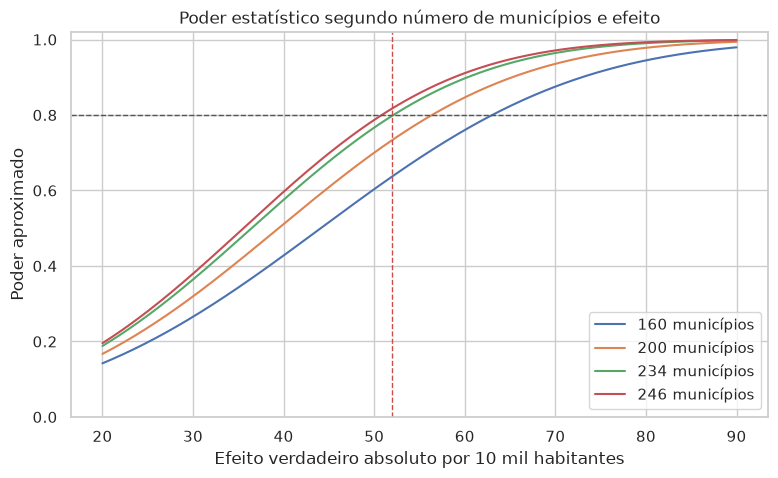

In [5]:
efeitos = np.linspace(20, 90, 300)
n_cenarios = [160, 200, 234, 246]

fig, ax = plt.subplots(figsize=(9, 5))
for n in n_cenarios:
    # Aproximação normal bilateral usada no planejamento.
    poder_delta = norm.cdf(efeitos * np.sqrt(n) / (2 * sigma_res) - norm.ppf(.975))
    ax.plot(efeitos, poder_delta, label=f"{n} municípios")
ax.axhline(.80, color="#555", linestyle="--", linewidth=1)
ax.axvline(52, color="#cc4c4c", linestyle="--", linewidth=1)
ax.set(
    xlabel="Efeito verdadeiro absoluto por 10 mil habitantes",
    ylabel="Poder aproximado",
    ylim=(0, 1.02),
    title="Poder estatístico segundo número de municípios e efeito",
)
ax.legend()
plt.show()

O cálculo requer 236 municípios sem perdas para detectar o MDE-alvo. Com 5%
de perda de clusters seriam necessários aproximadamente 249, ligeiramente mais
que os 246 disponíveis. A decisão é convidar **todos os 246 municípios**, com
123 em cada braço. Se 5% deixarem de fornecer o desfecho, a amostra efetiva será
próxima de 234 e o MDE alcançável ficará em torno de 52,1 por 10 mil.

Portanto, o desenho tem poder adequado apenas para efeitos municipais
moderados ou grandes. Um MDE de 20 por 10 mil, próximo da estimativa pontual
observacional da atividade 1, exigiria mais de mil clusters sob essas
premissas. Essa diferença é importante: um efeito relevante para gestores pode
ser menor do que o efeito que um estudo estadual consegue detectar.

O cálculo é feito no nível municipal e, por isso, não aplica um fator de
inflação por correlação intraclasse. Se o protocolo passasse a usar desfechos
individuais, seria necessário conhecer o número médio de pessoas por município
e o ICC, aplicando $DE=1+(m-1)\rho$ e considerando que o número de clusters —
não apenas o número de pessoas — determina grande parte da informação.

## Ilustração da alocação bloqueada

O código seguinte documenta um sorteio reproduzível para fins didáticos. No
experimento real, a lista de elegíveis, a semente, o algoritmo e as regras para
estratos ímpares seriam registrados antes de revelar a alocação. A execução
seria auditada por pessoa independente da equipe de implementação.

In [6]:
planejamento = df.copy()
planejamento["estrato_risco"] = pd.qcut(
    planejamento["taxa_icsap_pre"], 4, labels=["Q1", "Q2", "Q3", "Q4"]
)
planejamento["estrato_porte"] = pd.qcut(
    planejamento["populacao_2014"], 3, labels=["P1", "P2", "P3"]
)
planejamento["bloco"] = (
    planejamento["estrato_risco"].astype(str)
    + "–"
    + planejamento["estrato_porte"].astype(str)
)

rng = np.random.default_rng(SEED)
tamanhos = planejamento.groupby("bloco").size()
blocos_impares = tamanhos.index[tamanhos.mod(2).eq(1)].to_numpy()
blocos_com_extra = set(
    rng.choice(blocos_impares, size=len(blocos_impares) // 2, replace=False)
)

planejamento["oferta_prioritaria"] = 0
for bloco, indices in planejamento.groupby("bloco").groups.items():
    indices = np.asarray(list(indices))
    rng.shuffle(indices)
    n_tratado = len(indices) // 2 + int(bloco in blocos_com_extra)
    planejamento.loc[indices[:n_tratado], "oferta_prioritaria"] = 1

print(planejamento["oferta_prioritaria"].value_counts().sort_index())
pd.crosstab(
    planejamento["bloco"], planejamento["oferta_prioritaria"],
    margins=True,
).rename(columns={0: "Fluxo regular", 1: "Oferta prioritária"})

oferta_prioritaria
0    123
1    123
Name: count, dtype: int64


oferta_prioritaria,Fluxo regular,Oferta prioritária,All
bloco,,,
Q1–P1,14,14,28
Q1–P2,11,11,22
Q1–P3,6,6,12
Q2–P1,8,7,15
Q2–P2,9,10,19
Q2–P3,13,14,27
Q3–P1,9,9,18
Q3–P2,11,12,23
Q3–P3,10,10,20


In [7]:
covariaveis_balanceamento = [
    "taxa_icsap_pre", "taxa_clinicas_pre", "log_populacao"
]

def diferenca_padronizada(data, variavel):
    t = data.loc[data.oferta_prioritaria.eq(1), variavel]
    c = data.loc[data.oferta_prioritaria.eq(0), variavel]
    desvio = np.sqrt((t.var(ddof=1) + c.var(ddof=1)) / 2)
    return (t.mean() - c.mean()) / desvio

balanceamento_sorteio = pd.DataFrame({
    "Covariável": covariaveis_balanceamento,
    "Diferença padronizada": [
        diferenca_padronizada(planejamento, v)
        for v in covariaveis_balanceamento
    ],
})
balanceamento_sorteio.round(3)

,Covariável,Diferença padronizada
0,taxa_icsap_pre,-0.068
1,taxa_clinicas_pre,-0.058
2,log_populacao,0.020


A tabela de balanceamento descreve uma realização possível do sorteio; ela não
é um critério para refazer alocações até obter significância conveniente. Se o
protocolo adotar randomização restrita, o limite de desequilíbrio e o número de
listas candidatas devem ser definidos previamente. A análise incluirá os
blocos usados na randomização, independentemente do balanceamento observado.

## Plano de análise do ITT

A análise primária seguirá a designação original:

$$Y_{i,post}=\alpha+\tau Z_i+\gamma Y_{i,pre}+\lambda_{b(i)}+\varepsilon_i,$$

em que $\lambda_{b(i)}$ representa os blocos de randomização. O coeficiente
$\tau$ estima o ITT. Serão apresentados diferença ajustada, intervalo de 95% e
teste bilateral. Como verificação, também serão reportados diferença simples e
inferência por randomização compatível com o algoritmo de alocação.

Decisões pré-especificadas:

- analisar todos os municípios no braço sorteado, mesmo sem implementação;
- não ajustar por mediadores posteriores, como consultas realizadas;
- usar população contemporânea apenas como denominador previamente definido;
- verificar perdas do desfecho por braço e documentar mudanças de códigos;
- não escolher o modelo com base na significância observada;
- publicar protocolo, código de randomização e plano de análise antes do
  acesso aos resultados posteriores.

Embora o desfecho seja uma taxa municipal, análises de sensibilidade podem
usar contagens com a população como exposição e ponderação por precisão. A
estimativa não ponderada por município permanece primária porque corresponde
ao efeito médio sobre os municípios elegíveis.

## Não-conformidade: ITT e LATE

São esperadas duas formas de não-conformidade:

1. **não adesão no tratamento:** município sorteado pode não concluir a adesão,
   não oferecer condições de instalação ou não conseguir preencher/reter a
   vaga na janela prevista;
2. **contaminação do controle:** município no fluxo regular pode receber
   profissional por reposição, emergência judicial, outro ciclo ou modalidade
   de provimento.

Excluir esses municípios ou comparar apenas quem recebeu PMM destruiria a
comparabilidade criada pelo sorteio. A análise principal será, portanto, o
ITT. Em seguida será estimado o primeiro estágio:

$$\pi=E[D_i\mid Z_i=1]-E[D_i\mid Z_i=0].$$

Se a designação for relevante e satisfizer independência, exclusão e
monotonicidade, o efeito local do provimento para os **conformes** será

$$LATE=\frac{ITT}{\pi}.$$

Equivalentemente, pode-se estimar uma regressão por variáveis instrumentais em
dois estágios usando $Z_i$ como instrumento de $D_i$, preservando os blocos e a
linha de base. O LATE não é o efeito para todos os municípios: refere-se
àqueles cujo recebimento muda por causa da oferta prioritária.

In [8]:
# Cenários ilustrativos: o LATE e sua escala dependem do primeiro estágio.
itt_referencia = 52
cenarios_adesao = pd.DataFrame({
    "Recebimento se oferta": [0.90, 0.80, 0.70],
    "Recebimento no controle": [0.05, 0.10, 0.20],
})
cenarios_adesao["Primeiro estágio"] = (
    cenarios_adesao["Recebimento se oferta"]
    - cenarios_adesao["Recebimento no controle"]
)
cenarios_adesao["LATE correspondente a |ITT|=52"] = (
    itt_referencia / cenarios_adesao["Primeiro estágio"]
)
cenarios_adesao.round(2)

,Recebimento se oferta,Recebimento no controle,Primeiro estágio,LATE correspondente a |ITT|=52
0,0.9,0.05,0.85,61.18
1,0.8,0.10,0.70,74.29
2,0.7,0.20,0.50,104.00


Quanto menor o primeiro estágio, maior a escala do LATE correspondente a um
mesmo ITT e menor a precisão do estimador instrumental. Por isso, adesão e
contaminação devem ser monitoradas por registros administrativos, com datas de
oferta, aceite, entrada, permanência e número de profissionais. O estudo não
deve prometer poder para o LATE com base apenas no cálculo do ITT; um cálculo
específico dependerá de uma hipótese realista para o primeiro estágio.

## Riscos éticos

O sorteio só é defensável sob **equipoise** e escassez operacional: não há
certeza sobre o efeito nas ICSAP e não existem vagas suficientes para atender
todos simultaneamente. O desenho deve organizar a ordem de expansão, não
retirar médicos ou serviços existentes.

Salvaguardas propostas:

- usar lista de espera e garantir oferta posterior aos controles, se a política
  continuar e os resultados de segurança permitirem;
- manter o cuidado padrão e permitir exceção emergencial documentada, tratada
  como não-conformidade na análise ITT;
- publicar critérios de elegibilidade antes do sorteio e impedir manipulação
  política da lista;
- obter autorizações institucionais e avaliação ética para uso e vinculação de
  dados, com proteção de registros individuais;
- monitorar deslocamento de profissionais, desassistência em municípios
  vizinhos e eventos adversos de acesso;
- comunicar que a participação no estudo não garante resultado favorável e
  que o sorteio define prioridade temporal, não merecimento.

Municípios em situação de emergência ou com obrigação legal de atendimento
devem ser excluídos do sorteio e atendidos diretamente. Essa exclusão precisa
ocorrer antes da randomização e limita a população à qual o efeito se aplica.

## Validade externa e outras limitações

Mesmo com validade interna elevada, o resultado não se generaliza
automaticamente:

- Goiás tem organização regional, oferta médica e perfil epidemiológico
  próprios;
- municípios que aceitam participar podem diferir dos que recusam;
- excluir emergências e municípios sem condições mínimas restringe a população
  elegível;
- o efeito de oferta prioritária durante expansão escassa pode diferir do
  efeito de uma política universal em escala permanente;
- composição, experiência e permanência dos profissionais podem variar entre
  ciclos;
- deslocamento de pacientes e médicos pode criar interferência entre clusters;
- o SIH mede internações financiadas pelo SUS e não toda a utilização
  hospitalar;
- parâmetros históricos de 2013–2015 podem não representar a variabilidade de
  um experimento contemporâneo.

A validade externa deve ser discutida pela comparação entre participantes,
elegíveis não participantes e outros estados, e não apenas pelo tamanho da
amostra. Registrar contexto, implementação e heterogeneidade por porte e risco
ajuda futuras decisões de transporte do efeito.

## Conclusão

O desenho recomendado é um experimento por clusters municipais, com alocação
1:1 da oferta prioritária do PMM e bloqueio por taxa prévia de ICSAP e porte.
Essa escolha corresponde à unidade real de implementação, reduz contaminação
dentro do município e melhora a precisão em relação ao sorteio municipal
simples.

Com teste bilateral de 5%, poder de 80%, ajuste pela taxa prévia e
desvio-padrão residual histórico de aproximadamente 142,3, são necessários 236
municípios para detectar um MDE de 52 internações por 10 mil habitantes. Após
prever 5% de perda seriam necessários cerca de 249; como Goiás possui 246, o
plano inclui todos os municípios e alcança MDE próximo de 52,1 sob essa perda.
O estudo não terá poder adequado para efeitos pequenos.

A análise primária será o ITT da oferta, preservando os benefícios do sorteio.
Não adesão, vagas não preenchidas e entrada de controles por outros canais
serão documentadas, não usadas para excluir unidades. O LATE poderá ser
estimado com a oferta como instrumento do recebimento, desde que o primeiro
estágio e as hipóteses de exclusão e monotonicidade sejam plausíveis.

Eticamente, o sorteio deve ordenar uma expansão genuinamente escassa, manter o
cuidado padrão, proteger emergências e prever oferta posterior. O resultado
será internamente válido para os municípios elegíveis e participantes, mas sua
generalização dependerá do contexto, da adesão, da escala e dos spillovers.

## Referências e fontes

- BRASIL. Lei nº 12.871, de 22 de outubro de 2013. Institui o Programa Mais
  Médicos.
- BRASIL. Ministério da Saúde. *Programa de Provimento Federal – Programa Mais
  Médicos para o Brasil: série histórica*. Portal de Dados Abertos do SUS.
- GOIÁS. Secretaria de Estado da Saúde. *Internações por Condições Sensíveis à
  Atenção Primária*. Dados derivados do SIH/DATASUS.
- HAYES, R. J.; MOULTON, L. H. *Cluster Randomised Trials*. 2. ed. Boca Raton:
  CRC Press, 2017.
- HERNÁN, M. A.; ROBINS, J. M. *Causal Inference: What If*. Boca Raton:
  Chapman & Hall/CRC, 2020.
- ANGRIST, J. D.; PISCHKE, J.-S. *Mostly Harmless Econometrics*. Princeton:
  Princeton University Press, 2009.
- GERBER, A. S.; GREEN, D. P. *Field Experiments: Design, Analysis, and
  Interpretation*. New York: W. W. Norton, 2012.
- CONSORT. Extension for Cluster Randomised Trials. *BMJ*, 2012.

Os dados de planejamento e sua reconstrução estão documentados na atividade 1.